In [11]:
from astropy.io import fits
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

In [ ]:
# Configurar dispositivo para GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

data_files = glob.glob('data/spectra_data_100k*.pkl')
data_files = sorted(data_files)  # Ordena para garantizar un orden consistente

# Inicializar el diccionario donde se acumularán los datos
spectra_data = {}

# Cargar y combinar los datos de cada archivo encontrado
for file in data_files:
    with open(file, 'rb') as f:
        data_part = pickle.load(f)
    spectra_data.update(data_part)

print(f"Se han cargado {len(spectra_data)} espectros a partir de {len(data_files)} archivos.")

file_names = list(spectra_data.keys())
fluxes = [spectra_data[f]["flux"] for f in file_names]
wavelengths = [spectra_data[f]["wavelength"] for f in file_names]
redshifts = [spectra_data[f]["redshift"] for f in file_names]

# Concatenar flujo y longitud de onda como entrada al modelo
X = np.stack([fluxes, wavelengths], axis=1)  # Ahora tiene 10000 características por muestra
y = np.array(redshifts)

# Normalización
nsamples, nchannels, npoints = X.shape
X = X.reshape(nsamples, -1)

# scaler = StandardScaler()
# X = scaler.fit_transform(X)
# with open('extra/scaler_modelCNN_UPD4_100ktest.pkl', 'wb') as f:
#     pickle.dump(scaler, f)

with open('extra/scaler_modelCNN_UPD4_100ktest.pkl', 'rb') as f:
    scaler = pickle.load(f)
X = scaler.transform(X)

X = X.reshape(nsamples, nchannels, npoints)

# División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.00001, random_state=42)

# Convertir a tensores de PyTorch y mover a GPU si está disponible
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)

# Crear DataSets y DataLoaders
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

Usando dispositivo: cuda


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Configurar dispositivo para GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Número de puntos en cada espectro
num_points = 5000

# Definición del modelo que combina CNN y atención para resaltar las líneas de emisión
class AttentionCNN(nn.Module):
    def __init__(self, num_points):
        super(AttentionCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv1d(in_channels=2, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        
        # Después de las convoluciones, la dimensión embebida es 256
        self.embed_dim = 256
        
        # Se utiliza self-attention sobre la secuencia de características
        self.attention = nn.MultiheadAttention(embed_dim=self.embed_dim, num_heads=4, batch_first=True)
        
        # Calcular el tamaño de salida después de las capas convolucionales (5 capas de MaxPool1d con kernel_size=2)
        conv_output_size = num_points // 32
        
        # Capas finales para la regresión del redshift
        self.fc_layers = nn.Sequential(
            nn.Linear(self.embed_dim * conv_output_size, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5),  # Regularización con Dropout
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # x tiene forma (batch_size, 2, num_points)
        features = self.conv_layers(x)             # Resultado: (batch_size, 256, seq_length)
        features = features.permute(0, 2, 1)         # Reordenar a (batch_size, seq_length, embed_dim)
        # Aplicar self-attention (usando las mismas características como query, key y value)
        attn_output, _ = self.attention(features, features, features)
        # Aplanar la salida para la capa fully connected
        attn_output = attn_output.contiguous().view(attn_output.size(0), -1)
        out = self.fc_layers(attn_output)
        return out

# Instanciar el modelo y moverlo a GPU
modelAttentionCNN = AttentionCNN(num_points).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(modelAttentionCNN.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

print("Modelo configurado correctamente.")

Usando dispositivo: cuda
Modelo configurado correctamente.


In [ ]:
# # Entrenar el modelo
# num_epochs = 99
# for epoch in range(num_epochs):
#     modelAttentionCNN.train()
#     running_loss = 0.0
#     for batch_X, batch_y in train_loader:
#         batch_X, batch_y = batch_X.to(device), batch_y.to(device)
#         optimizer.zero_grad()
#         outputs = modelAttentionCNN(batch_X)
#         loss = criterion(outputs, batch_y)
#         loss.backward()
#         optimizer.step()
#         running_loss += loss.item() * batch_X.size(0)
#     epoch_loss = running_loss / len(train_dataset)

#     # Evaluación en el conjunto de validación
#     modelAttentionCNN.eval()
#     val_loss = 0.0
#     with torch.no_grad():
#         for batch_X, batch_y in test_loader:
#             batch_X, batch_y = batch_X.to(device), batch_y.to(device)
#             outputs = modelAttentionCNN(batch_X)
#             loss = criterion(outputs, batch_y)
#             val_loss += loss.item() * batch_X.size(0)
#     val_loss /= len(test_dataset)

#     # Actualizar la tasa de aprendizaje según la pérdida de validación
#     scheduler.step(val_loss)
#     current_lr = optimizer.param_groups[0]['lr']

#     print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {current_lr:.10f}")

# # Evaluación final en el conjunto de prueba utilizando MAE
# mae_loss = nn.L1Loss()
# modelAttentionCNN.eval()
# test_mae = 0.0
# with torch.no_grad():
#     for batch_X, batch_y in test_loader:
#         batch_X, batch_y = batch_X.to(device), batch_y.to(device)
#         outputs = modelAttentionCNN(batch_X)
#         loss = mae_loss(outputs, batch_y)
#         test_mae += loss.item() * batch_X.size(0)
# test_mae /= len(test_dataset)
# print(f"Error absoluto medio en el conjunto de prueba: {test_mae:.4f}")

# # Guardar los parámetros del modelo
# checkpoint = {
#     'epoch': num_epochs,
#     'model_state_dict': modelAttentionCNN.state_dict(),
#     'optimizer_state_dict': optimizer.state_dict(),
#     'scheduler_state_dict': scheduler.state_dict()
# }
# torch.save(checkpoint, 'storage/modelCNN_UPD5_100ktest.pth')

Epoch 1/99, Loss: 1.4177, Val Loss: 0.8318, LR: 0.0001000000
Epoch 2/99, Loss: 1.2788, Val Loss: 0.8324, LR: 0.0001000000
Epoch 3/99, Loss: 1.1789, Val Loss: 0.7201, LR: 0.0001000000
Epoch 4/99, Loss: 1.0165, Val Loss: 0.5338, LR: 0.0001000000
Epoch 5/99, Loss: 0.8688, Val Loss: 0.2326, LR: 0.0001000000
Epoch 6/99, Loss: 0.7700, Val Loss: 0.7438, LR: 0.0001000000
Epoch 7/99, Loss: 0.7261, Val Loss: 0.3119, LR: 0.0001000000
Epoch 8/99, Loss: 0.7126, Val Loss: 0.2773, LR: 0.0001000000
Epoch 9/99, Loss: 0.6801, Val Loss: 0.2194, LR: 0.0001000000
Epoch 10/99, Loss: 0.6797, Val Loss: 0.2428, LR: 0.0001000000
Epoch 11/99, Loss: 0.6430, Val Loss: 0.1021, LR: 0.0001000000
Epoch 12/99, Loss: 0.6370, Val Loss: 0.2223, LR: 0.0001000000
Epoch 13/99, Loss: 0.6167, Val Loss: 0.0709, LR: 0.0001000000
Epoch 14/99, Loss: 0.6079, Val Loss: 0.1866, LR: 0.0001000000
Epoch 15/99, Loss: 0.6076, Val Loss: 0.3308, LR: 0.0001000000
Epoch 16/99, Loss: 0.5983, Val Loss: 0.1633, LR: 0.0001000000
Epoch 17/99, Loss

In [ ]:
# Seguir entrenando el modelo
checkpoint = torch.load('storage/modelCNN_UPD5_100ktest.pth', weights_only=False)
modelAttentionCNN.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
start_epoch = checkpoint['epoch']

# Definir el número total de epochs que deseas entrenar
num_epochs = 400

# Continuar el entrenamiento desde el epoch donde se quedó
for epoch in range(start_epoch, num_epochs + 1):
    modelAttentionCNN.train()
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = modelAttentionCNN(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_X.size(0)
    epoch_loss = running_loss / len(train_dataset)

    # Evaluación en el conjunto de validación
    modelAttentionCNN.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = modelAttentionCNN(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)
    val_loss /= len(test_dataset)

    # Actualizar la tasa de aprendizaje según la pérdida de validación
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    if epoch % 5 == 0:
        print(f"Epoch {epoch}/{num_epochs}, Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {current_lr:.10f}")

# Evaluación final en el conjunto de prueba utilizando MAE
mae_loss = nn.L1Loss()
modelAttentionCNN.eval()
test_mae = 0.0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = modelAttentionCNN(batch_X)
        loss = mae_loss(outputs, batch_y)
        test_mae += loss.item() * batch_X.size(0)
test_mae /= len(test_dataset)
print(f"Error absoluto medio en el conjunto de prueba: {test_mae:.4f}")

# Guardar los parámetros del modelo y el scaler
checkpoint = {
    'epoch': num_epochs,
    'model_state_dict': modelAttentionCNN.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict()
}
torch.save(checkpoint, 'storage/modelCNN_UPD5_100ktest.pth')





# Epoch 1/99, Loss: 1.4177, Val Loss: 0.8318, LR: 0.0001000000
# Epoch 2/99, Loss: 1.2788, Val Loss: 0.8324, LR: 0.0001000000
# Epoch 3/99, Loss: 1.1789, Val Loss: 0.7201, LR: 0.0001000000
# Epoch 4/99, Loss: 1.0165, Val Loss: 0.5338, LR: 0.0001000000
# Epoch 5/99, Loss: 0.8688, Val Loss: 0.2326, LR: 0.0001000000
# Epoch 6/99, Loss: 0.7700, Val Loss: 0.7438, LR: 0.0001000000
# Epoch 7/99, Loss: 0.7261, Val Loss: 0.3119, LR: 0.0001000000
# Epoch 8/99, Loss: 0.7126, Val Loss: 0.2773, LR: 0.0001000000
# Epoch 9/99, Loss: 0.6801, Val Loss: 0.2194, LR: 0.0001000000
# Epoch 10/99, Loss: 0.6797, Val Loss: 0.2428, LR: 0.0001000000
# Epoch 11/99, Loss: 0.6430, Val Loss: 0.1021, LR: 0.0001000000
# Epoch 12/99, Loss: 0.6370, Val Loss: 0.2223, LR: 0.0001000000
# Epoch 13/99, Loss: 0.6167, Val Loss: 0.0709, LR: 0.0001000000
# Epoch 14/99, Loss: 0.6079, Val Loss: 0.1866, LR: 0.0001000000
# Epoch 15/99, Loss: 0.6076, Val Loss: 0.3308, LR: 0.0001000000
# Epoch 16/99, Loss: 0.5983, Val Loss: 0.1633, LR: 0.0001000000
# Epoch 17/99, Loss: 0.5770, Val Loss: 0.4447, LR: 0.0001000000
# Epoch 18/99, Loss: 0.5639, Val Loss: 0.0331, LR: 0.0001000000
# Epoch 19/99, Loss: 0.5576, Val Loss: 0.0729, LR: 0.0001000000
# Epoch 20/99, Loss: 0.5721, Val Loss: 0.0844, LR: 0.0001000000
# Epoch 21/99, Loss: 0.5412, Val Loss: 0.1878, LR: 0.0001000000
# Epoch 22/99, Loss: 0.5386, Val Loss: 0.1178, LR: 0.0001000000
# Epoch 23/99, Loss: 0.5323, Val Loss: 0.1758, LR: 0.0001000000
# Epoch 24/99, Loss: 0.5175, Val Loss: 0.0528, LR: 0.0001000000
# Epoch 25/99, Loss: 0.5120, Val Loss: 0.1322, LR: 0.0001000000
# Epoch 26/99, Loss: 0.5102, Val Loss: 0.1322, LR: 0.0001000000
# Epoch 27/99, Loss: 0.4968, Val Loss: 0.0215, LR: 0.0001000000
# Epoch 28/99, Loss: 0.4883, Val Loss: 0.0007, LR: 0.0001000000
# Epoch 29/99, Loss: 0.5015, Val Loss: 0.1819, LR: 0.0001000000
# Epoch 30/99, Loss: 0.4904, Val Loss: 0.0504, LR: 0.0001000000
# Epoch 31/99, Loss: 0.4834, Val Loss: 0.0180, LR: 0.0001000000
# Epoch 32/99, Loss: 0.4707, Val Loss: 0.0348, LR: 0.0001000000
# Epoch 33/99, Loss: 0.4732, Val Loss: 0.0862, LR: 0.0001000000
# Epoch 34/99, Loss: 0.4668, Val Loss: 0.0406, LR: 0.0001000000
# Epoch 35/99, Loss: 0.4697, Val Loss: 0.0894, LR: 0.0001000000
# Epoch 36/99, Loss: 0.4592, Val Loss: 0.1119, LR: 0.0001000000
# Epoch 37/99, Loss: 0.4469, Val Loss: 0.0592, LR: 0.0001000000
# Epoch 38/99, Loss: 0.4482, Val Loss: 0.1404, LR: 0.0001000000
# Epoch 39/99, Loss: 0.4630, Val Loss: 0.0971, LR: 0.0000500000
# Epoch 40/99, Loss: 0.4139, Val Loss: 0.0754, LR: 0.0000500000
# Epoch 41/99, Loss: 0.4057, Val Loss: 0.1168, LR: 0.0000500000
# Epoch 42/99, Loss: 0.4053, Val Loss: 0.0959, LR: 0.0000500000
# Epoch 43/99, Loss: 0.4000, Val Loss: 0.0199, LR: 0.0000500000
# Epoch 44/99, Loss: 0.4002, Val Loss: 0.0373, LR: 0.0000500000
# Epoch 45/99, Loss: 0.3969, Val Loss: 0.0262, LR: 0.0000500000
# Epoch 46/99, Loss: 0.3914, Val Loss: 0.1547, LR: 0.0000500000
# Epoch 47/99, Loss: 0.3882, Val Loss: 0.0598, LR: 0.0000500000
# Epoch 48/99, Loss: 0.3880, Val Loss: 0.0506, LR: 0.0000500000
# Epoch 49/99, Loss: 0.3834, Val Loss: 0.1233, LR: 0.0000500000
# Epoch 50/99, Loss: 0.3830, Val Loss: 0.0870, LR: 0.0000250000
# Epoch 51/99, Loss: 0.3614, Val Loss: 0.1014, LR: 0.0000250000
# Epoch 52/99, Loss: 0.3579, Val Loss: 0.0529, LR: 0.0000250000
# Epoch 53/99, Loss: 0.3540, Val Loss: 0.0774, LR: 0.0000250000
# Epoch 54/99, Loss: 0.3498, Val Loss: 0.1046, LR: 0.0000250000
# Epoch 55/99, Loss: 0.3507, Val Loss: 0.0317, LR: 0.0000250000
# Epoch 56/99, Loss: 0.3511, Val Loss: 0.0633, LR: 0.0000250000
# Epoch 57/99, Loss: 0.3465, Val Loss: 0.0706, LR: 0.0000250000
# Epoch 58/99, Loss: 0.3475, Val Loss: 0.0616, LR: 0.0000250000
# Epoch 59/99, Loss: 0.3430, Val Loss: 0.0569, LR: 0.0000250000
# Epoch 60/99, Loss: 0.3398, Val Loss: 0.0148, LR: 0.0000250000
# Epoch 61/99, Loss: 0.3398, Val Loss: 0.0390, LR: 0.0000125000
# Epoch 62/99, Loss: 0.3263, Val Loss: 0.0404, LR: 0.0000125000
# Epoch 63/99, Loss: 0.3257, Val Loss: 0.0374, LR: 0.0000125000
# Epoch 64/99, Loss: 0.3270, Val Loss: 0.0367, LR: 0.0000125000
# Epoch 65/99, Loss: 0.3251, Val Loss: 0.0186, LR: 0.0000125000
# Epoch 66/99, Loss: 0.3240, Val Loss: 0.0425, LR: 0.0000125000
# Epoch 67/99, Loss: 0.3217, Val Loss: 0.0295, LR: 0.0000125000
# Epoch 68/99, Loss: 0.3210, Val Loss: 0.0177, LR: 0.0000125000
# Epoch 69/99, Loss: 0.3176, Val Loss: 0.0632, LR: 0.0000125000
# Epoch 70/99, Loss: 0.3203, Val Loss: 0.0312, LR: 0.0000125000
# Epoch 71/99, Loss: 0.3175, Val Loss: 0.0297, LR: 0.0000125000
# Epoch 72/99, Loss: 0.3162, Val Loss: 0.0149, LR: 0.0000062500
# Epoch 73/99, Loss: 0.3090, Val Loss: 0.0365, LR: 0.0000062500
# Epoch 74/99, Loss: 0.3092, Val Loss: 0.0391, LR: 0.0000062500
# Epoch 75/99, Loss: 0.3078, Val Loss: 0.0240, LR: 0.0000062500
# Epoch 76/99, Loss: 0.3073, Val Loss: 0.0274, LR: 0.0000062500
# Epoch 77/99, Loss: 0.3055, Val Loss: 0.0136, LR: 0.0000062500
# Epoch 78/99, Loss: 0.3069, Val Loss: 0.0529, LR: 0.0000062500
# Epoch 79/99, Loss: 0.3059, Val Loss: 0.0333, LR: 0.0000062500
# Epoch 80/99, Loss: 0.3041, Val Loss: 0.0198, LR: 0.0000062500
# Epoch 81/99, Loss: 0.3049, Val Loss: 0.0202, LR: 0.0000062500
# Epoch 82/99, Loss: 0.3025, Val Loss: 0.0277, LR: 0.0000062500
# Epoch 83/99, Loss: 0.3041, Val Loss: 0.0274, LR: 0.0000031250
# Epoch 84/99, Loss: 0.2990, Val Loss: 0.0586, LR: 0.0000031250
# Epoch 85/99, Loss: 0.2962, Val Loss: 0.0307, LR: 0.0000031250
# Epoch 86/99, Loss: 0.2989, Val Loss: 0.0247, LR: 0.0000031250
# Epoch 87/99, Loss: 0.2955, Val Loss: 0.0338, LR: 0.0000031250
# Epoch 88/99, Loss: 0.2987, Val Loss: 0.0503, LR: 0.0000031250
# Epoch 89/99, Loss: 0.2971, Val Loss: 0.0328, LR: 0.0000031250
# Epoch 90/99, Loss: 0.2963, Val Loss: 0.0463, LR: 0.0000031250
# Epoch 91/99, Loss: 0.2968, Val Loss: 0.0452, LR: 0.0000031250
# Epoch 92/99, Loss: 0.2951, Val Loss: 0.0283, LR: 0.0000031250
# Epoch 93/99, Loss: 0.2981, Val Loss: 0.0393, LR: 0.0000031250
# Epoch 94/99, Loss: 0.2956, Val Loss: 0.0362, LR: 0.0000015625
# Epoch 95/99, Loss: 0.2923, Val Loss: 0.0367, LR: 0.0000015625
# Epoch 96/99, Loss: 0.2914, Val Loss: 0.0411, LR: 0.0000015625
# Epoch 97/99, Loss: 0.2925, Val Loss: 0.0337, LR: 0.0000015625
# Epoch 98/99, Loss: 0.2919, Val Loss: 0.0421, LR: 0.0000015625
# Epoch 99/99, Loss: 0.2906, Val Loss: 0.0416, LR: 0.0000015625
# Epoch 100/200, Loss: 0.2949, Val Loss: 0.0474, LR: 0.0000015625
# Epoch 105/200, Loss: 0.2908, Val Loss: 0.0315, LR: 0.0000007813
# Epoch 110/200, Loss: 0.2909, Val Loss: 0.0329, LR: 0.0000007813
# Epoch 115/200, Loss: 0.2908, Val Loss: 0.0412, LR: 0.0000003906
# Epoch 120/200, Loss: 0.2880, Val Loss: 0.0376, LR: 0.0000003906
# Epoch 125/200, Loss: 0.2899, Val Loss: 0.0373, LR: 0.0000003906
# Epoch 130/200, Loss: 0.2879, Val Loss: 0.0366, LR: 0.0000001953
# Epoch 135/200, Loss: 0.2870, Val Loss: 0.0303, LR: 0.0000001953
# Epoch 140/200, Loss: 0.2871, Val Loss: 0.0362, LR: 0.0000000977
# Epoch 145/200, Loss: 0.2880, Val Loss: 0.0370, LR: 0.0000000977
# Epoch 150/200, Loss: 0.2894, Val Loss: 0.0368, LR: 0.0000000488
# Epoch 155/200, Loss: 0.2888, Val Loss: 0.0361, LR: 0.0000000488
# Epoch 160/200, Loss: 0.2907, Val Loss: 0.0359, LR: 0.0000000244
# Epoch 165/200, Loss: 0.2882, Val Loss: 0.0359, LR: 0.0000000244
# Epoch 170/200, Loss: 0.2881, Val Loss: 0.0364, LR: 0.0000000122
# Epoch 175/200, Loss: 0.2856, Val Loss: 0.0366, LR: 0.0000000122
# Epoch 180/200, Loss: 0.2893, Val Loss: 0.0363, LR: 0.0000000122
# Epoch 185/200, Loss: 0.2882, Val Loss: 0.0364, LR: 0.0000000122
# Epoch 190/200, Loss: 0.2866, Val Loss: 0.0364, LR: 0.0000000122
# Epoch 195/200, Loss: 0.2868, Val Loss: 0.0364, LR: 0.0000000122
# Epoch 200/200, Loss: 0.2858, Val Loss: 0.0364, LR: 0.0000000122

Epoch 100/200, Loss: 0.2949, Val Loss: 0.0474, LR: 0.0000015625
Epoch 105/200, Loss: 0.2908, Val Loss: 0.0315, LR: 0.0000007813
Epoch 110/200, Loss: 0.2909, Val Loss: 0.0329, LR: 0.0000007813
Epoch 115/200, Loss: 0.2908, Val Loss: 0.0412, LR: 0.0000003906
Epoch 120/200, Loss: 0.2880, Val Loss: 0.0376, LR: 0.0000003906
Epoch 125/200, Loss: 0.2899, Val Loss: 0.0373, LR: 0.0000003906
Epoch 130/200, Loss: 0.2879, Val Loss: 0.0366, LR: 0.0000001953
Epoch 135/200, Loss: 0.2870, Val Loss: 0.0303, LR: 0.0000001953
Epoch 140/200, Loss: 0.2871, Val Loss: 0.0362, LR: 0.0000000977
Epoch 145/200, Loss: 0.2880, Val Loss: 0.0370, LR: 0.0000000977
Epoch 150/200, Loss: 0.2894, Val Loss: 0.0368, LR: 0.0000000488
Epoch 155/200, Loss: 0.2888, Val Loss: 0.0361, LR: 0.0000000488
Epoch 160/200, Loss: 0.2907, Val Loss: 0.0359, LR: 0.0000000244
Epoch 165/200, Loss: 0.2882, Val Loss: 0.0359, LR: 0.0000000244
Epoch 170/200, Loss: 0.2881, Val Loss: 0.0364, LR: 0.0000000122
Epoch 175/200, Loss: 0.2856, Val Loss: 0

Redshift real: 0.61740834
Redshift predicho: 0.3672903776168823


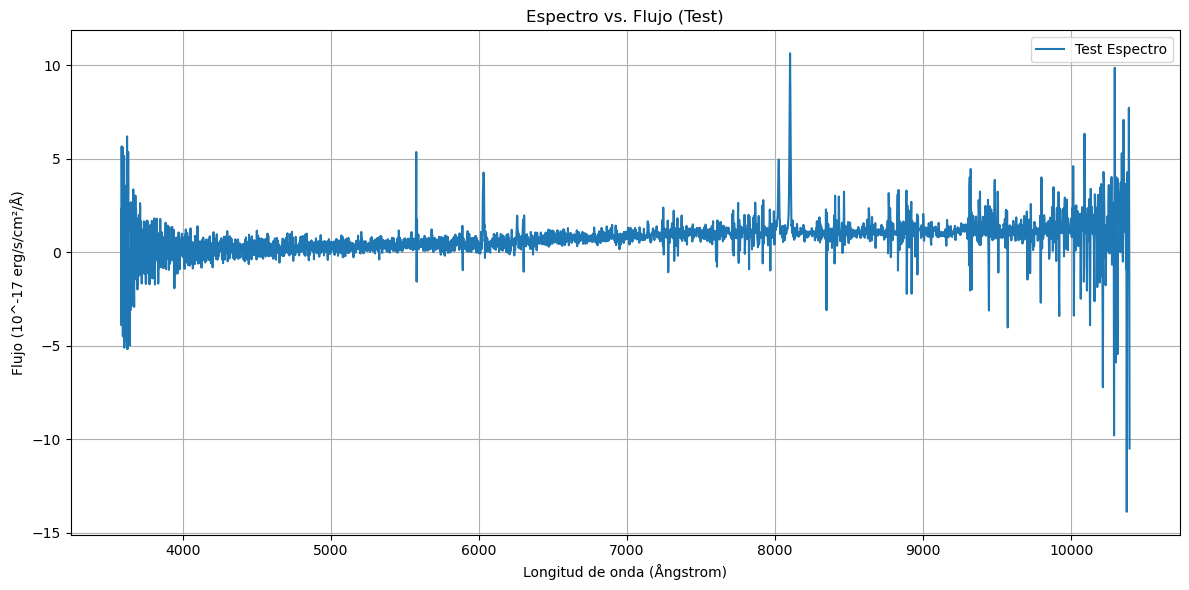

In [ ]:
# Obtener la lista inicial de archivos FITS
folder_path = r'spectrums'
files = [f for f in os.listdir(folder_path) if f.endswith('.fits')]
files = random.sample(files, len(files))
file_path = os.path.join(folder_path, files[0])

checkpoint = torch.load('storage/modelCNN_UPD5_100ktest.pth', weights_only=False)
modelAttentionCNN.load_state_dict(checkpoint['model_state_dict'])
with open('extra/scaler_modelCNN_UPD_100ktest.pkl', 'rb') as f:
    scaler = pickle.load(f)


with fits.open(file_path) as hdul:
    test_flux = hdul[1].data["flux"]
    test_loglam = hdul[1].data["loglam"]
    test_redshift = hdul[2].data["Z"][0]  # Asumiendo que Z es un array y queremos el primer valor

test_wavelength = 10 ** test_loglam

def expand_points(wavelength, flux, target_count=5000):
    # Convertir a listas para facilitar las inserciones
    wl = list(wavelength)
    fl = list(flux)
    
    # Calcular las diferencias absolutas entre puntos consecutivos
    diffs = [abs(fl[i+1] - fl[i]) for i in range(len(fl)-1)]
    # Obtener los índices ordenados de mayor a menor diferencia
    sorted_indices = sorted(range(len(diffs)), key=lambda i: diffs[i], reverse=True)
    
    # Insertar nuevos puntos utilizando los índices ordenados
    while len(wl) < target_count:
        # Se recorre la lista de índices en orden descendente para evitar problemas con el reordenamiento
        for idx in sorted_indices:
            if len(wl) >= target_count:
                break
            # Calcular la interpolación lineal entre el punto idx y el siguiente
            new_wl = (wl[idx] + wl[idx+1]) / 2
            new_fl = (fl[idx] + fl[idx+1]) / 2
            # Insertar el nuevo punto en la posición correspondiente
            wl.insert(idx+1, new_wl)
            fl.insert(idx+1, new_fl)
    
    return np.array(wl), np.array(fl)

test_wavelength, test_flux = expand_points(test_wavelength, test_flux, target_count=num_points)

# Preprocesamiento para el modelo
# Canal 0: flux; Canal 1: wavelength
input_data = np.stack([test_flux, test_wavelength], axis=0)  # (2, 5000) 2 canales de tamaño 5000
input_data = input_data.reshape(1, 2, num_points)            # (1, 2, 5000) 1 muestra, 2 canales, 5000 puntos/canal

# Normalización
nsamples, nchannels, npoints = input_data.shape # Guardar dimensionalidad inicial
input_flat = input_data.reshape(nsamples, -1) # Aplanar/concatenar (1, 10000)
input_scaled = scaler.transform(input_flat) # Normalizar
input_scaled = input_scaled.reshape(nsamples, nchannels, npoints) # Recuperar dimensionalidad incial

# Convertir a tensor
input_tensor = torch.tensor(input_scaled, dtype=torch.float32)
input_tensor = input_tensor.to(device)

# Evaluar el modelo
with torch.no_grad():
    predicted_redshift = modelAttentionCNN(input_tensor)

print("Redshift real:", test_redshift)
print("Redshift predicho:", predicted_redshift.item())

plt.figure(figsize=(12, 6))
plt.plot(test_wavelength, test_flux, label="Test Espectro")
plt.xlabel("Longitud de onda (Ångstrom)")
plt.ylabel("Flujo (10^-17 erg/s/cm²/Å)")
plt.title("Espectro vs. Flujo (Test)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()